# Multiplots

In order to check the data quality of many stations and many years, we need an efficient method to rapidly scan stations with good data and identify stations with data issues which will require further inspection.



In this exercise, you will learn how to generate solar data quality multiplots using the solarpy Python package.

In [ ]:
# Install pvlib and solarpy as these are not standard packages.
!pip install pvlib
!pip install git+https://github.com/assessingsolar/solarpy.git

In [2]:
import pandas as pd  # library for data analysis
import matplotlib.pyplot as plt  # library for plotting
import numpy as np  # library for math and linear algebra

import pvlib  # library for PV and solar calculations
import solarpy  # library for solar data quality control

c:\Users\arajen\AppData\Local\miniconda3\envs\solarpy\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


## Step 1: Read data


👉 The first step is to load an data from the Baseline Surface Radiation Network (BSRN). You can find a list of stations [here](https://dataportals.pangaea.de/bsrn/stations) and an overview of which stations has data for which years is provided [here](https://dataportals.pangaea.de/bsrn/?q=LR0100).

The username and password are provided on Learn.

In [ ]:
data, meta = pvlib.iotools.get_bsrn(
    station="CAB",
    start="2025-01-01",
    end="2025-12-31",
    username="redacted",
    password="redacted",
)

data

,ghi,ghi_std,ghi_min,ghi_max,dni,dni_std,dni_min,dni_max,dhi,dhi_std,dhi_min,dhi_max,lwd,lwd_std,lwd_min,lwd_max,temp_air,relative_humidity,pressure
2025-01-01 00:00:00+00:00,0.0,0.1,0.0,0.0,0.0,0.1,0.0,0.0,-1.0,0.1,-1.0,-1.0,345.0,0.1,345.0,345.0,8.1,85.8,1016.0
2025-01-01 00:01:00+00:00,0.0,0.1,0.0,0.0,0.0,0.1,0.0,0.0,-1.0,0.1,-1.0,-1.0,345.0,0.1,344.0,345.0,8.2,85.4,1016.0
2025-01-01 00:02:00+00:00,0.0,0.1,0.0,0.0,0.0,0.1,0.0,0.0,-1.0,0.1,-1.0,-1.0,345.0,0.1,344.0,345.0,8.2,85.0,1016.0
2025-01-01 00:03:00+00:00,0.0,0.1,-1.0,0.0,0.0,0.1,0.0,0.0,-1.0,0.1,-1.0,0.0,345.0,0.2,345.0,345.0,8.2,85.8,1016.0
2025-01-01 00:04:00+00:00,0.0,0.1,0.0,0.0,0.0,0.1,0.0,0.0,-1.0,0.1,-1.0,-1.0,345.0,0.2,344.0,345.0,8.2,86.0,1016.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 23:55:00+00:00,0.0,0.0,0.0,0.0,1.0,0.1,1.0,1.0,0.0,0.1,0.0,0.0,318.0,0.2,317.0,318.0,3.8,82.0,1015.0
2025-12-31 23:56:00+00:00,0.0,0.1,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.1,0.0,0.0,318.0,0.2,317.0,318.0,3.6,83.0,1015.0
2025-12-31 23:57:00+00:00,0.0,0.0,0.0,0.0,1.0,0.1,1.0,1.0,0.0,0.1,0.0,0.0,318.0,0.2,317.0,318.0,3.5,84.0,1015.0
2025-12-31 23:58:00+00:00,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,317.0,0.1,317.0,318.0,3.5,84.0,1015.0


## Step 2: Calculate solar position
Once we have retrieved the irradiance data, we need to calculate the solar position. This cell is already filled out, so you only need to execute it and go to the next step.

In [4]:
solarposition = pvlib.solarposition.get_solarposition(
    time=data.index, latitude=meta['latitude'], longitude=meta['longitude'],
)

data['solar_zenith'] = solarposition['apparent_zenith']
data['solar_azimuth'] = solarposition['azimuth']

## Step 3: Generate multiplot


The solarpy Python package provides a convenient function to generate the solar data quality multiplots.

Execute the cell below to generate the multiplot.

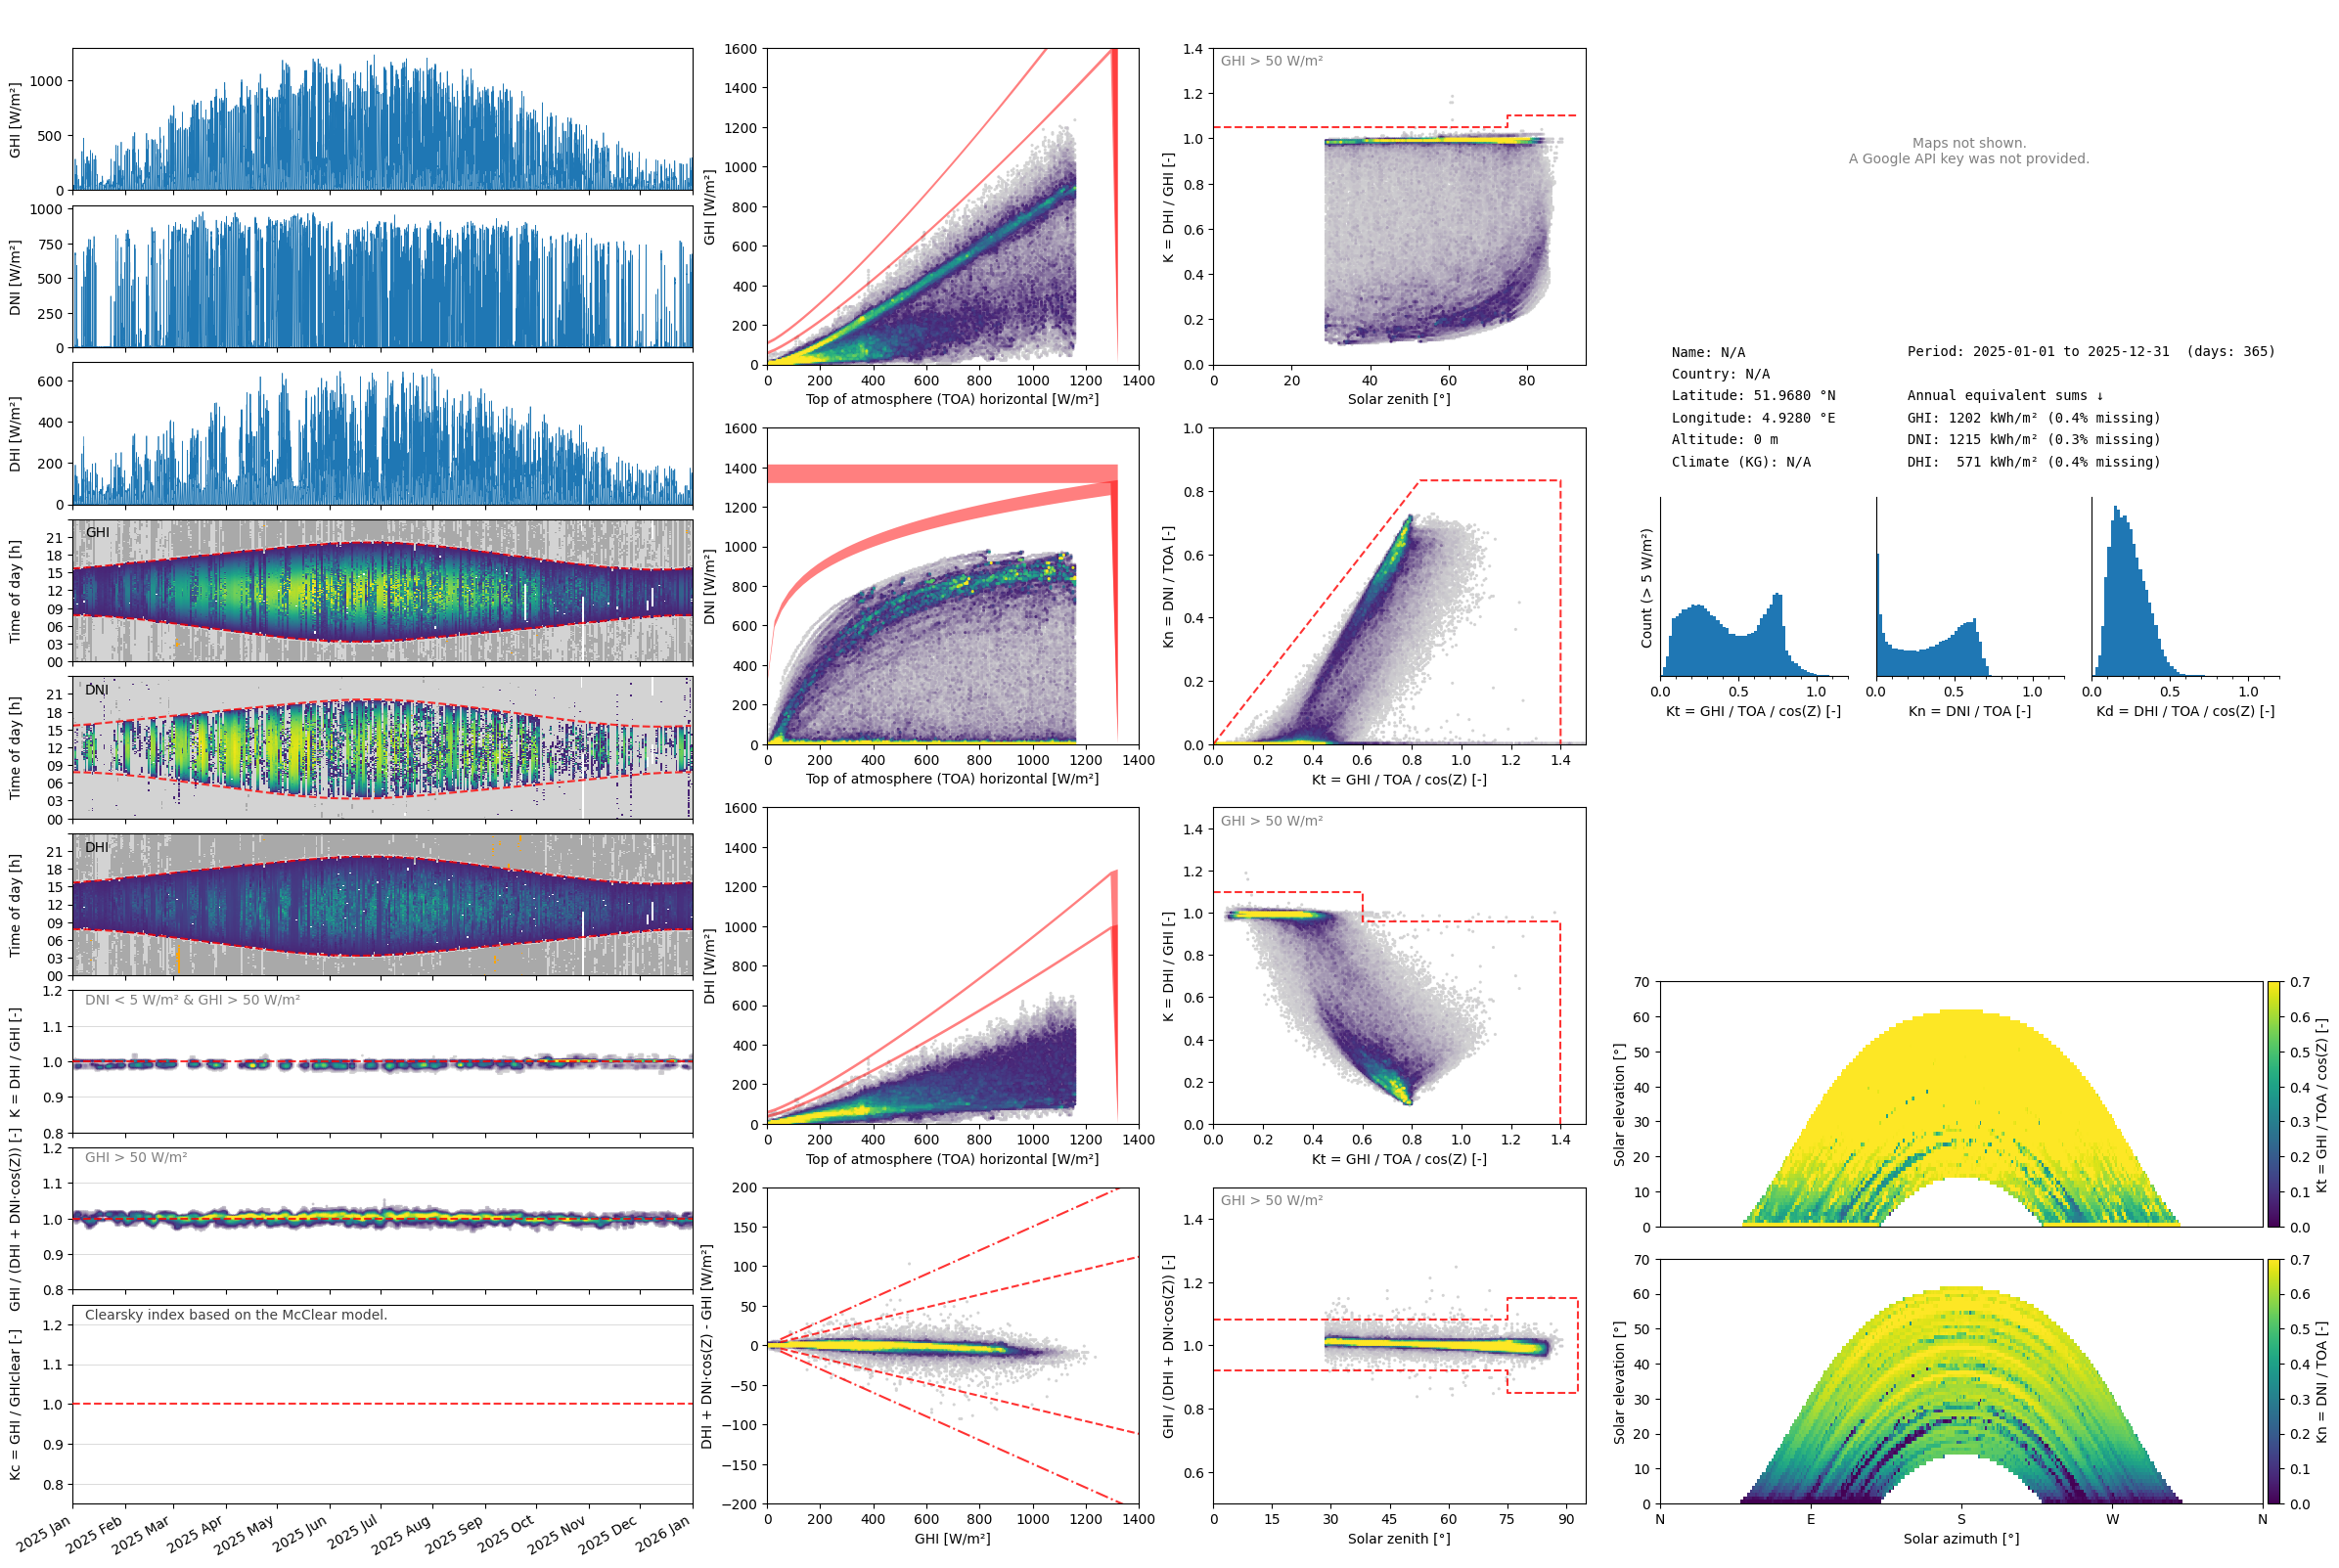

In [5]:
fig, axes = solarpy.plotting.multiplot(
    times=data.index,
    data=data,
    meta=meta,
)

## Step 4: Investigate different datasets

The first example dataset was from the station Cabauw (CAB) for the year 2025. The Cabauw station is known for having very good data quality.

However, there are many stations, also within the BSRN, that have data issues. In this exercise your job is to explore multiplots from different stations and identify potential issues. To do this, modify the code above, changing the station and year, and re-execute the code cells in Steps 1-3.

List of stations and years with potential data issues:
- CNR 2020
- E13 2018
- FLO 2024
- INO 2022
- MNM 2022
- NEW 2019
- RUN 2021

Issues:
- Change of calibration coefficient
- Instrument with poor cosine reponse
- Shading from vegetation or buildings
- Poor cleaning of instruments
- High thermal offsets
- Tracker issue
- Time drift

Can you identify which of the above stations/years corresponds to the list of issues?